In [1]:
"""
Financial Engineering - Assignment 3.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf


START_DATE     = "2018-01-01"     # backtest start
END_DATE       = "2025-12-31"     # backtest end
STARTING_CASH  = 1000000          # starting capital in dollars
FAST_MA        = 50               # short moving average
SLOW_MA        = 200              # long moving average
RISK_FREE_RATE = 0.03             # annual risk-free rate, for Sharpe / Sortino
TRADING_DAYS   = 252              # trading days in a year

# Each bucket - target share of the portfolio (the 40/30/30).
# Within a bucket, the held stocks are equal-weighted.
BUCKETS = {
    "Uranium Miners & Fuel": {
        "stocks": ["CCJ", "UEC", "NXE", "DNN"],
        "target": 0.40,
    },
    "Reactor Developers": {
        "stocks": ["OKLO", "SMR", "NNE", "LEU"],
        "target": 0.30,
    },
    "Nuclear Utilities": {
        "stocks": ["VST", "CEG", "TLN"],
        "target": 0.30,
    },
}

FUND_STOCKS = [s for b in BUCKETS.values() for s in b["stocks"]]

# benchmarks
BENCHMARKS = {
    "SPY": "S&P 500",
    "QQQ": "NASDAQ-100",
    "TLT": "US Treasuries",
    "URA": "Nuclear Sector Benchmark"
}

In [2]:
def get_prices(tickers):
    print(f"Downloading prices for {len(tickers)} symbols...")
    data = yf.download(tickers, start=START_DATE, end=END_DATE,
                       auto_adjust=True, progress=False)

    prices = data["Close"]
    if isinstance(prices, pd.Series):           # 
        prices = prices.to_frame()

    # Drop any day where every price is missing.
    prices = prices.dropna(how="all")
    if prices.empty:
        raise ValueError("No price data returned -- check tickers / dates.")

    print(f"Got {len(prices)} days of data.\n")
    return prices
  

In [3]:
def momentum_signals(prices):
    fast = prices.rolling(FAST_MA).mean()       # 50-day average
    slow = prices.rolling(SLOW_MA).mean()       # 200-day average
    return (fast > slow).astype(int)


def bucket_weights(held):
    """
        Uranium Miners & Fuel  -> 40%
        Reactor Developers     -> 30%
        Nuclear Utilities      -> 30%

    """
    weights = pd.DataFrame(0.0, index=held.index, columns=held.columns)

    for bucket in BUCKETS.values():
        stocks = bucket["stocks"]
        target = bucket["target"]
        held_in_bucket = held[stocks]
        count = held_in_bucket.sum(axis=1)
        per_stock = held_in_bucket.div(count, axis=0).fillna(0) * target
        weights[stocks] = per_stock

    return weights

In [4]:
def backtest_strategy(prices):

    signals = momentum_signals(prices)
    weights = bucket_weights(signals)

    daily_returns = prices.pct_change()
    weights_yesterday = weights.shift(1)

    # Missing data treatment
    contributions = (weights_yesterday * daily_returns).fillna(0.0)
    invested_return = contributions.sum(axis=1)

    # Capital not allocated to any stock earns the risk-free rate
    cash_weight = 1.0 - weights_yesterday.sum(axis=1)
    rf_daily = RISK_FREE_RATE / TRADING_DAYS
    cash_return = cash_weight * rf_daily

    strategy_daily_return = invested_return + cash_return

    portfolio_value = (1 + strategy_daily_return).cumprod() * STARTING_CASH
    return portfolio_value.dropna()


def backtest_buy_and_hold(prices):
    daily_returns = prices.pct_change().fillna(0)
    return (1 + daily_returns.iloc[:, 0]).cumprod() * STARTING_CASH

In [5]:
def drawdown(portfolio_value):

    running_peak = portfolio_value.cummax()
    return portfolio_value / running_peak - 1


def performance_metrics(portfolio_value):
    
    returns = portfolio_value.pct_change().dropna()

    # Total return
    total_return = portfolio_value.iloc[-1] / portfolio_value.iloc[0] - 1

    # CAGR
    years = len(returns) / TRADING_DAYS
    cagr = (1 + total_return) ** (1 / years) - 1

    # Volatility (annualized)
    volatility = returns.std() * np.sqrt(TRADING_DAYS)

    # Sharpe ratio
    rf_daily = RISK_FREE_RATE / TRADING_DAYS
    excess = returns - rf_daily
    sharpe = (excess.mean() / returns.std()) * np.sqrt(TRADING_DAYS)

    # Sortino ratio

    shortfall = np.minimum(excess, 0.0)
    downside_dev = np.sqrt((shortfall ** 2).mean()) * np.sqrt(TRADING_DAYS)
    sortino = (excess.mean() * TRADING_DAYS / downside_dev
               if downside_dev > 0 else 0.0)

    # Max drawdown
    max_drawdown = drawdown(portfolio_value).min()

    return {
        "Total Return": total_return,
        "CAGR": cagr,
        "Volatility": volatility,
        "Sharpe Ratio": sharpe,
        "Sortino Ratio": sortino,
        "Max Drawdown": max_drawdown,
    }


def print_metrics(name, metrics):
    print(f"  {name}")
    print(f"    Total Return : {metrics['Total Return'] * 100:8.1f}%")
    print(f"    CAGR         : {metrics['CAGR'] * 100:8.1f}%")
    print(f"    Volatility   : {metrics['Volatility'] * 100:8.1f}%")
    print(f"    Sharpe Ratio : {metrics['Sharpe Ratio']:8.2f}")
    print(f"    Sortino Ratio: {metrics['Sortino Ratio']:8.2f}")
    print(f"    Max Drawdown : {metrics['Max Drawdown'] * 100:8.1f}%")
    print()

In [6]:
def plot_results(fund_value, benchmark_values):
    """Two-panel chart: equity curves on top, fund drawdown below."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8),
                                   sharex=True,
                                   gridspec_kw={"height_ratios": [3, 1]})

    fig.suptitle("Nuclear Fund vs Benchmarks", fontweight="bold")

    # Top panel - equity curves
    ax1.plot(fund_value.index, fund_value.values,
             label="Nuclear Fund", linewidth=2.5, color="navy")
    for name, value in benchmark_values.items():
        ax1.plot(value.index, value.values, label=name, linewidth=1.2)
    ax1.set_ylabel("Portfolio Value ($)")
    ax1.set_yscale("log")  # log scale 
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Bottom panel - Drawdown
    fund_dd = drawdown(fund_value) * 100
    ax2.fill_between(fund_dd.index, fund_dd.values, 0,
                     color="firebrick", alpha=0.4)
    ax2.plot(fund_dd.index, fund_dd.values, color="firebrick", linewidth=1)
    ax2.set_ylabel("Fund Drawdown (%)")
    ax2.set_xlabel("Date")
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("backtest_results.png", dpi=130)
    plt.show()

  Nuclear Fund - Backtest
Got 2010 days of data.

Got 2010 days of data.

Got 2010 days of data.

Got 2010 days of data.

Got 2010 days of data.

Performance Results
----------------------------------------------------------
  Nuclear Fund (Momentum + 40/30/30 Buckets)
    Total Return :   1230.3%
    CAGR         :     38.4%
    Volatility   :     38.6%
    Sharpe Ratio :     0.96
    Sortino Ratio:     1.44
    Max Drawdown :    -44.7%

  SPY buy-and-hold (S&P 500)
    Total Return :    189.6%
    CAGR         :     14.3%
    Volatility   :     19.5%
    Sharpe Ratio :     0.63
    Sortino Ratio:     0.88
    Max Drawdown :    -33.7%

  QQQ buy-and-hold (NASDAQ-100)
    Total Return :    311.8%
    CAGR         :     19.4%
    Volatility   :     24.1%
    Sharpe Ratio :     0.73
    Sortino Ratio:     1.04
    Max Drawdown :    -35.1%

  TLT buy-and-hold (US Treasuries)
    Total Return :    -12.6%
    CAGR         :     -1.7%
    Volatility   :     15.8%
    Sharpe Ratio :    -0.22


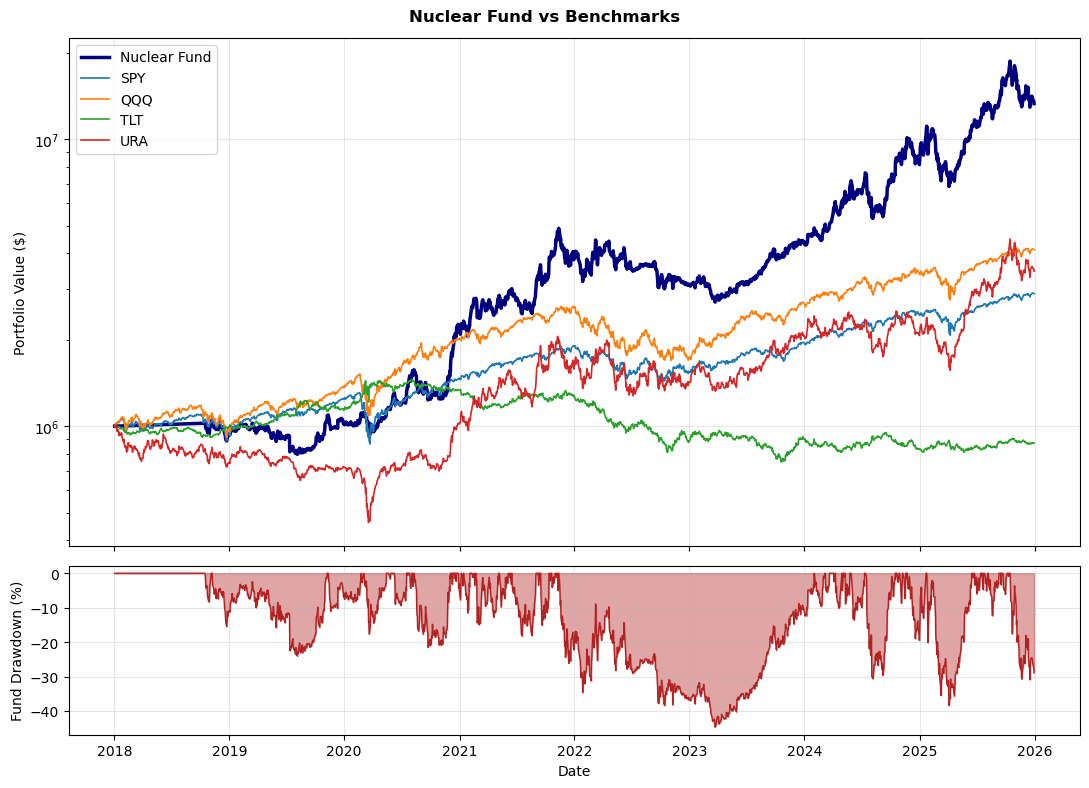

In [9]:
def main():
    print("  Nuclear Fund - Backtest")

    # Fund momentum strategy
    fund_prices = get_prices(FUND_STOCKS)
    fund_value = backtest_strategy(fund_prices)

    # Buy-and-hold benchmarks
    benchmark_values = {}
    for ticker in BENCHMARKS:
        prices = get_prices([ticker])
        benchmark_values[ticker] = backtest_buy_and_hold(prices)

    print("Performance Results")
    print("-" * 58)
    fund_metrics = performance_metrics(fund_value)
    print_metrics("Nuclear Fund (Momentum + 40/30/30 Buckets)", fund_metrics)

    benchmark_metrics = {}
    for ticker, label in BENCHMARKS.items():
        m = performance_metrics(benchmark_values[ticker])
        benchmark_metrics[ticker] = m
        print_metrics(f"{ticker} buy-and-hold ({label})", m)

    print("-" * 58)
    print("Verdict (risk-adjusted, by Sharpe ratio)")
    fund_sharpe = fund_metrics["Sharpe Ratio"]
    for ticker in BENCHMARKS:
        bench_sharpe = benchmark_metrics[ticker]["Sharpe Ratio"]
        verdict = "Beat" if fund_sharpe > bench_sharpe else "trailed"
        print(f"  Fund {verdict} {ticker} "
              f"(Sharpe {fund_sharpe:.2f} vs {bench_sharpe:.2f})")
    print()

    plot_results(fund_value, benchmark_values)

main()